In [1]:
#Name - Atharv Kashiv
#roll - 2501940030

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult.csv


In [ ]:
df = pd.read_csv("adult.csv")

In [ ]:
# ================================
# 1. Preprocessing
# ================================

# Handle missing values
df.replace(" ?", np.nan, inplace=True)
df.dropna(inplace=True)

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split features & target
X = df.drop("income", axis=1)
y = df["income"]

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
# ================================
# 2. Model
# ================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ================================
# 3. Compile & Train
# ================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=20,
                    batch_size=32)


Epoch 1/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8215 - loss: 0.3922 - val_accuracy: 0.8522 - val_loss: 0.3256
Epoch 2/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8406 - loss: 0.3437 - val_accuracy: 0.8503 - val_loss: 0.3197
Epoch 3/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8451 - loss: 0.3360 - val_accuracy: 0.8507 - val_loss: 0.3162
Epoch 4/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8456 - loss: 0.3327 - val_accuracy: 0.8501 - val_loss: 0.3141
Epoch 5/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8467 - loss: 0.3303 - val_accuracy: 0.8539 - val_loss: 0.3142
Epoch 6/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8472 - loss: 0.3294 - val_accuracy: 0.8520 - val_loss: 0.3127
Epoch 7/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8463 - loss: 0.3272 - val_accuracy: 0.8536 - val_loss: 0.3139
Epoch 8/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8479 - loss: 0.3270 - val_accuracy: 0.

In [ ]:
# ================================
# 4. Evaluation
# ================================
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8465 - loss: 0.3153
Accuracy: 0.8464609384536743


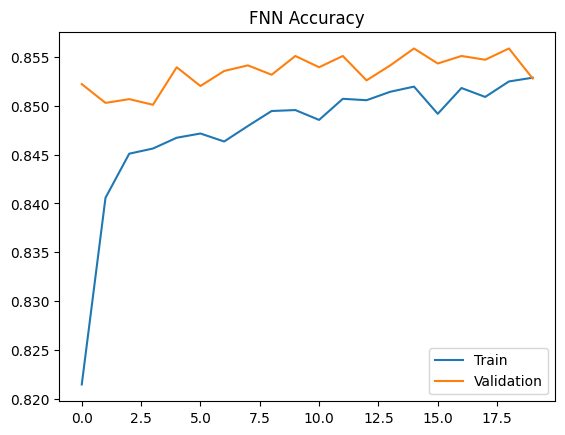

In [ ]:
# ================================
# 5. Plot
# ================================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("FNN Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()